# 1. Análise Exploratória dos Dados — Consumo Energético

Este notebook tem como objetivo compreender o comportamento do consumo energético da Zona 1 antes da etapa de modelagem.

A análise explora a distribuição dos dados, evolução temporal, padrões sazonais, tendência, estacionariedade, autocorrelação e relação entre o consumo e as variáveis meteorológicas.

O objetivo é identificar características relevantes da série e reunir evidências que orientem a construção das features e a escolha das estratégias de modelagem.

# 2. Importação das Bibliotecas

São importadas as bibliotecas utilizadas para manipulação dos dados, visualização gráfica e análise estatística da série temporal.

Também são carregadas ferramentas para análise de autocorrelação, decomposição sazonal e testes de estacionariedade.

In [1]:
# Manipulação e processamento dos dados
import pandas as pd
import numpy as np

# Visualização gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# Análise de autocorrelação
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Decomposição da série temporal
from statsmodels.tsa.seasonal import seasonal_decompose

# Teste de estacionariedade
from statsmodels.tsa.stattools import adfuller

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


# 3. Carregamento e Validação Inicial dos Dados

A base tratada é carregada e preparada para a análise exploratória, com a conversão da variável `data_hora` para índice temporal.

Em seguida, são realizadas verificações de consistência para confirmar a estrutura da série, a ausência de valores ausentes, a ordenação cronológica, a frequência regular de 10 minutos e o período disponível para análise.

Por fim, o escopo do estudo é direcionado ao consumo energético da Zona 1 (`consumo_zona_1`), mantendo as variáveis meteorológicas como possíveis fatores explicativos e removendo os consumos das demais zonas.

In [2]:
dados = pd.read_csv("../data/dados_tratados.csv")
dados["data_hora"] = pd.to_datetime(dados["data_hora"], format="%Y-%m-%d %H:%M:%S")
dados = dados.set_index("data_hora")
dados.head()

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1,consumo_zona_2,consumo_zona_3
data_hora,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
# Fazendo Validação Rápida
print(f"Classe do Index -> {type(dados.index)}")
print(f"\nShape -> {dados.shape}")

print(f"\nValores Ausentes -> {dados.isna().sum().sum()}")

print(f"\nOrdenado -> {dados.index.is_monotonic_increasing}")
print(f"\nFrequência -> {pd.infer_freq(dados.index)}")

print(f"Período -> {dados.index.min().date()} até {dados.index.max().date()}")

Classe do Index -> <class 'pandas.DatetimeIndex'>

Shape -> (52416, 8)

Valores Ausentes -> 0

Ordenado -> True

Frequência -> 10min
Período -> 2017-01-01 até 2017-12-30


In [4]:
# Iremos selecionar apenas o cosumo da Zona 1
dados = dados.drop(columns=["consumo_zona_2", "consumo_zona_3"])

dados.columns

Index(['temperatura', 'umidade', 'velocidade_vento', 'fluxo_difuso_geral',
       'fluxo_difuso', 'consumo_zona_1'],
      dtype='str')

# 4. Análise Exploratória dos Dados

A Análise Exploratória dos Dados tem como objetivo compreender o comportamento da série de consumo energético antes da etapa de modelagem.

Nesta seção, são investigadas a distribuição do consumo, seus padrões temporais, relações com variáveis meteorológicas, sazonalidade e propriedades estatísticas da série.



## 4.1 Estatísticas Descritivas do Consumo

Inicialmente, são analisadas as principais estatísticas descritivas da variável `consumo_zona_1`, incluindo média, mediana, desvio padrão, quartis e valores mínimo e máximo.

A série apresenta consumo médio de aproximadamente **32.345**, enquanto a mediana é próxima de **32.266**, indicando valores centrais bastante semelhantes.

Em seguida, a distribuição do consumo é visualizada por meio de um histograma, com destaque para a média e a mediana. Essa análise permite avaliar a concentração dos valores, a dispersão dos dados e possíveis indícios de assimetria na distribuição.

In [5]:
print("=== Estatísticas Descritivas ===")
print(dados["consumo_zona_1"].describe().round(3))

=== Estatísticas Descritivas ===
count    52416.000
mean     32344.971
std       7130.563
min      13895.696
25%      26310.669
50%      32265.920
75%      37309.018
max      52204.395
Name: consumo_zona_1, dtype: float64


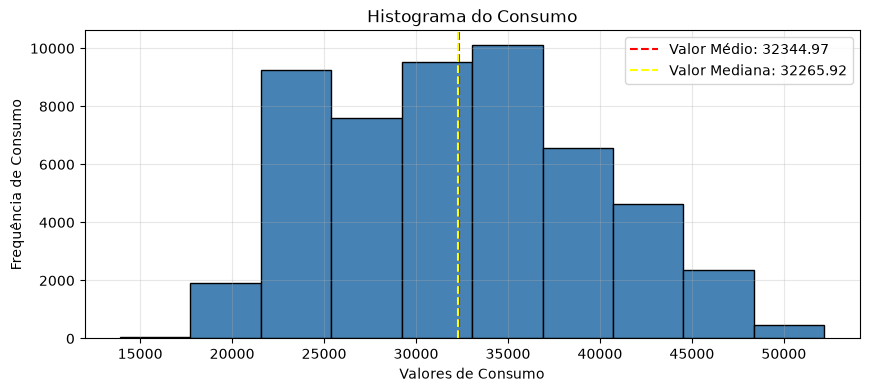

In [6]:
valor_medio = dados["consumo_zona_1"].mean()
valor_mediana = dados["consumo_zona_1"].median()

plt.figure(figsize=(10, 4))

plt.hist(dados["consumo_zona_1"], color="steelblue", edgecolor='black')
plt.axvline(dados["consumo_zona_1"].mean(), color="red", linestyle='--', label=f"Valor Médio: {valor_medio:.2f}")
plt.axvline(dados["consumo_zona_1"].median(), color="yellow", linestyle='--', label=f"Valor Mediana: {valor_mediana:.2f}")

plt.title("Histograma do Consumo")
plt.xlabel("Valores de Consumo")
plt.ylabel("Frequência de Consumo")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observação

A distribuição do consumo apresenta maior concentração em torno da faixa central dos dados, com média e mediana muito próximas (**32.345** e **32.266**, respectivamente).

Essa proximidade sugere uma distribuição relativamente equilibrada em torno do centro, sem evidência de assimetria acentuada. Ao mesmo tempo, observa-se uma amplitude considerável entre os menores e maiores valores de consumo, indicando variações relevantes na demanda energética ao longo do período analisado.

Essas variações reforçam a importância de investigar, nas próximas etapas, os padrões temporais e sazonais que podem explicar os diferentes níveis de consumo observados.

## 4.2 Visualização da Série Temporal

A evolução do consumo energético é analisada ao longo de 2017 a partir da média diária da Zona 1.

Essa visualização permite identificar mudanças no nível de consumo, períodos de maior demanda e possíveis padrões sazonais ao longo do ano.

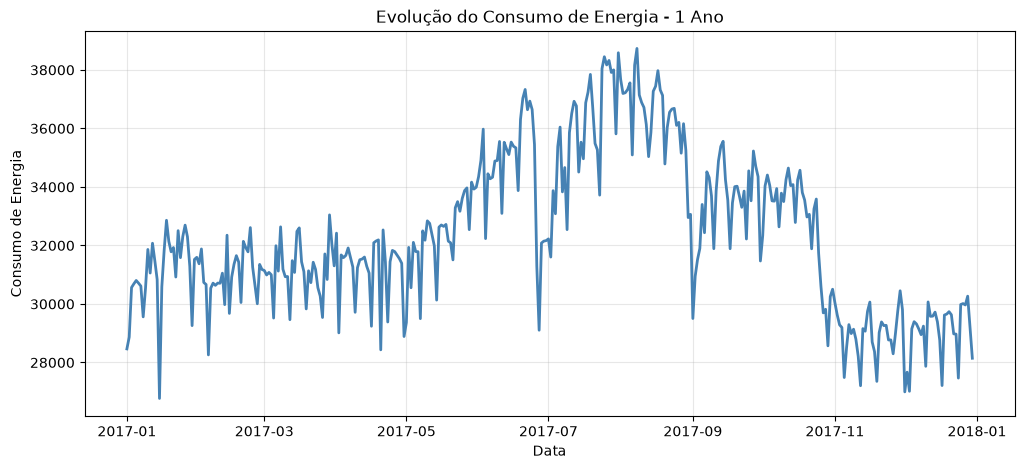

In [7]:
consumo_diario = dados["consumo_zona_1"].resample('D').mean()

plt.figure(figsize=(12,5))

plt.plot(consumo_diario.index, consumo_diario, color='steelblue', linewidth=2.0)
plt.title("Evolução do Consumo de Energia - 1 Ano")
plt.xlabel("Data")
plt.ylabel("Consumo de Energia")
plt.grid(alpha=0.3)
plt.show()

### Observação

O consumo apresenta crescimento ao longo do primeiro semestre, atingindo níveis mais elevados entre junho e agosto.

A partir de setembro, observa-se uma redução gradual, com níveis mais baixos no final do ano, indicando um possível padrão sazonal na série.

### 4.2.1 Médias Móveis

As médias móveis de 3 e 7 dias são utilizadas para suavizar as oscilações de curto prazo da série e destacar com maior clareza sua tendência ao longo do tempo.

Essa comparação ajuda a diferenciar variações pontuais de movimentos mais persistentes no consumo energético.

In [8]:
dados_mm = dados.copy()

dados_mm["dados_mm3_dias"] = dados["consumo_zona_1"].rolling(432).mean()

dados_mm["dados_mm7_dias"] = dados["consumo_zona_1"].rolling(1008).mean()

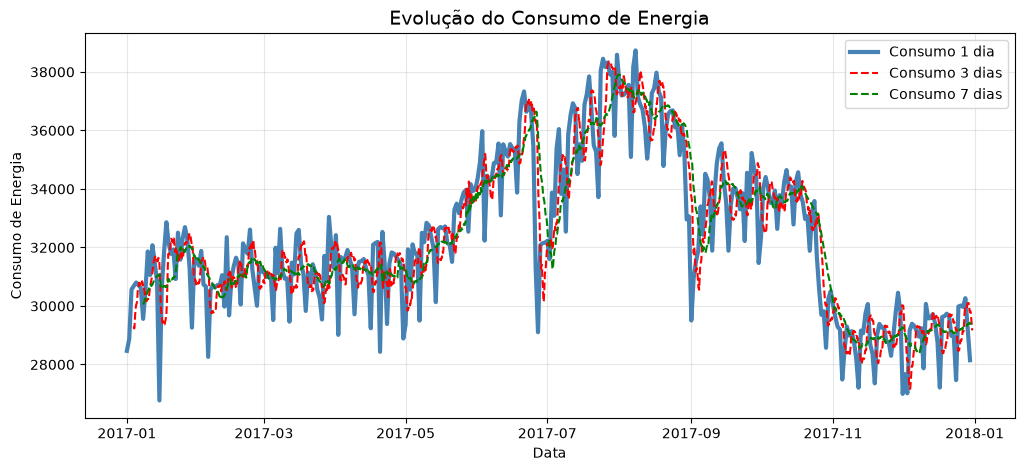

In [9]:
plt.figure(figsize=(12,5))

plt.plot(consumo_diario.index, consumo_diario, color="steelblue", label="Consumo 1 dia", linewidth=3.0)
plt.plot(dados_mm["dados_mm3_dias"], color="red", label="Consumo 3 dias", linewidth=1.5, linestyle='--')
plt.plot(dados_mm["dados_mm7_dias"], color="green", label="Consumo 7 dias", linewidth=1.5, linestyle='--')

plt.title("Evolução do Consumo de Energia", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Consumo de Energia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observação

As médias móveis acompanham o comportamento geral da série, reduzindo parte da variabilidade diária.

A média de 3 dias responde mais rapidamente às mudanças no consumo, enquanto a média de 7 dias apresenta uma trajetória mais suavizada, evidenciando melhor os movimentos de tendência ao longo do ano.

## 4.3 Sazonalidade — Consumo Médio por Mês

O consumo médio é analisado por mês para identificar possíveis padrões sazonais ao longo do ano.

A média geral da série é utilizada como referência para destacar os períodos com consumo acima ou abaixo do comportamento médio anual.

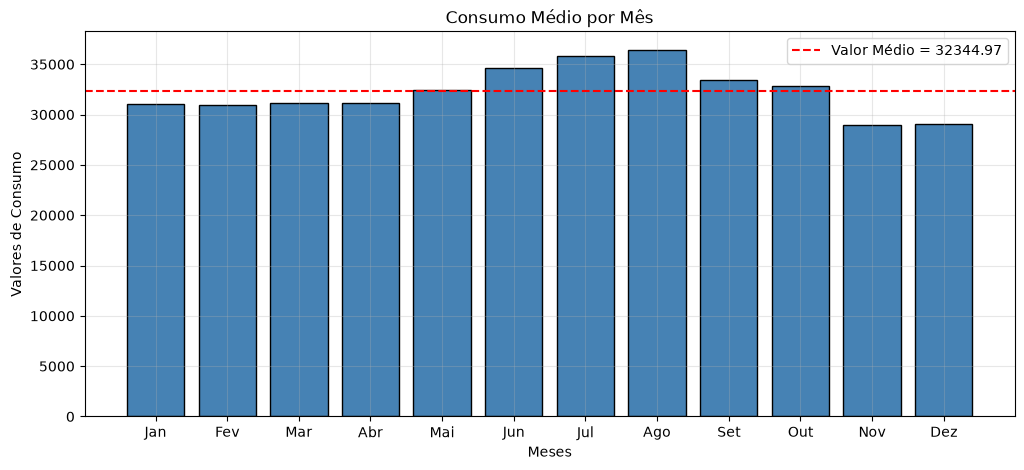

In [10]:
nomes_meses = ['Jan','Fev','Mar','Abr', 'Mai' ,'Jun' , 'Jul' ,'Ago' ,'Set' , 'Out' ,'Nov', 'Dez' ]
valor_medio = dados["consumo_zona_1"].mean()

media_mes = dados.groupby(dados.index.month)["consumo_zona_1"].mean()

fig, ax = plt.subplots(figsize=(12,5))

ax.bar(nomes_meses, media_mes.values, color='steelblue', edgecolor='black')
ax.axhline(valor_medio, color="red", linestyle='--', label=f"Valor Médio = {valor_medio:.2f}")
ax.set_title("Consumo Médio por Mês")
ax.set_xlabel("Meses")
ax.set_ylabel("Valores de Consumo")
ax.legend()
plt.grid(alpha=0.3)
plt.show()

### Observação

O consumo apresenta elevação entre junho e agosto, com pico médio em agosto, ficando acima da média anual nesse período.

Nos meses finais do ano, especialmente novembro e dezembro, observa-se redução mais acentuada do consumo, reforçando a presença de um padrão sazonal ao longo de 2017.

### 4.3.1 Consumo Médio por Dia da Semana

O consumo médio é analisado por dia da semana para identificar possíveis diferenças no padrão de demanda entre dias úteis e finais de semana.

A média geral da série é utilizada como referência para facilitar a comparação entre os diferentes dias.

In [39]:
dados_semana = dados.copy()

dados_semana["dia_da_semana"] = dados_semana.index.dayofweek

In [41]:
mapa_dias = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

dados_semana["dia_semana_nome"] = (dados_semana["dia_da_semana"].map(mapa_dias))

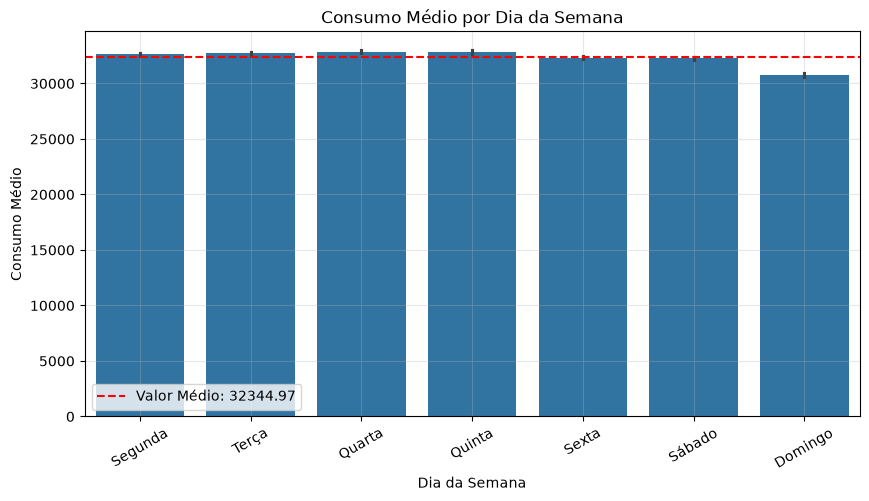

In [45]:
ordem_dias = ["Segunda","Terça","Quarta","Quinta","Sexta","Sábado","Domingo"]

plt.figure(figsize=(10, 5))

sns.barplot(data=dados_semana, x="dia_semana_nome", y="consumo_zona_1", order=ordem_dias)
plt.axhline(dados_semana["consumo_zona_1"].mean(), color="red", linestyle='--', label=f"Valor Médio: {dados_semana["consumo_zona_1"].mean():.2f}")

plt.title("Consumo Médio por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Consumo Médio")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Observação

O consumo permanece relativamente estável entre segunda e sábado, com valores próximos ou ligeiramente acima da média geral.

No domingo, observa-se uma redução mais evidente no consumo médio, indicando um possível efeito do dia da semana sobre a demanda energética.

## 4.4 Decomposição da Série

A série de consumo é decomposta em seus principais componentes: nível observado, tendência, sazonalidade e resíduos.

Foi utilizada uma decomposição aditiva com período de **144 observações**, correspondente a um ciclo diário em dados registrados a cada 10 minutos.

In [11]:
serie = dados["consumo_zona_1"]
decomp_adit = seasonal_decompose(serie, model='additive', period=144)

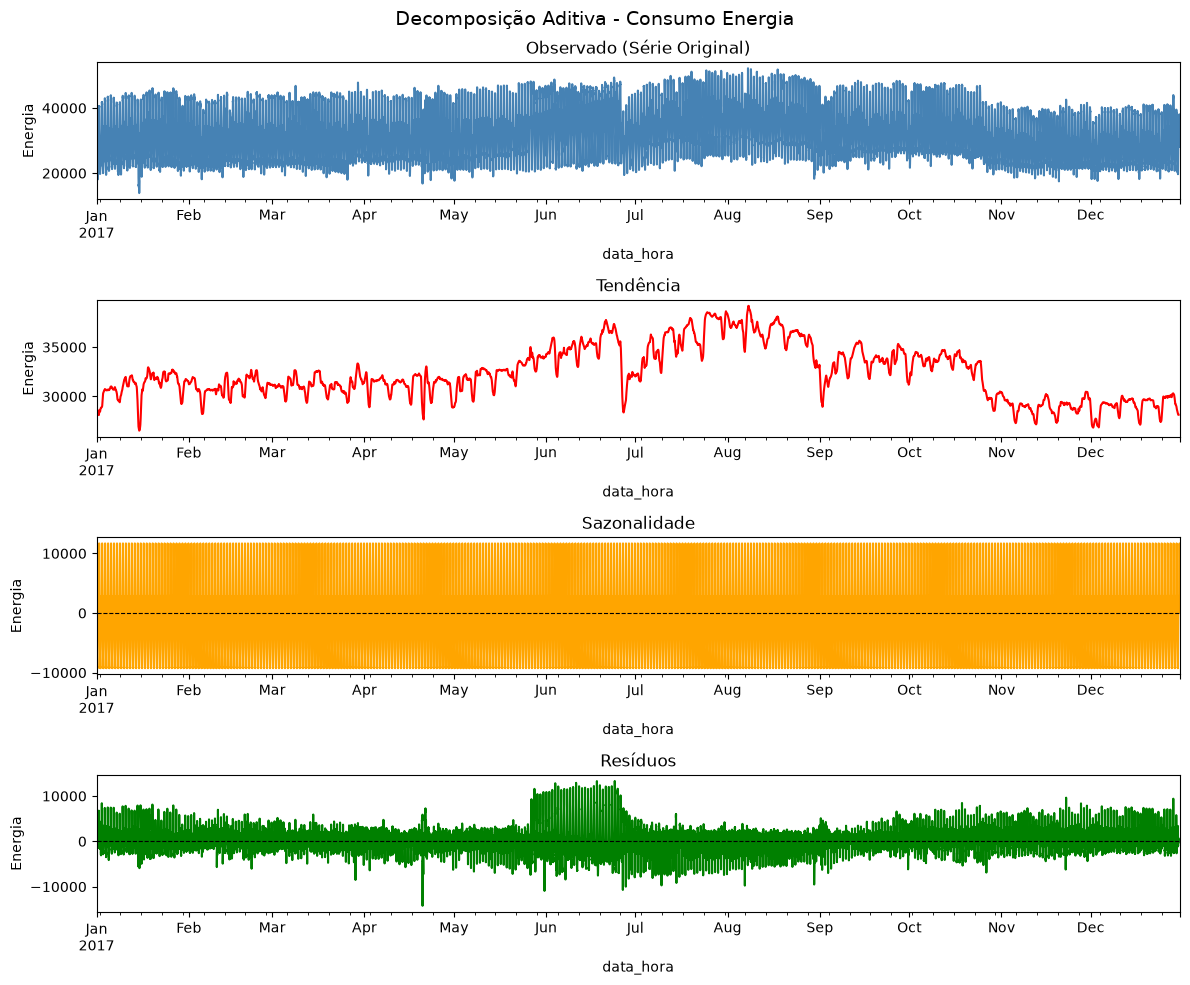

In [12]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10))

decomp_adit.observed.plot(ax=ax[0], color='steelblue')
ax[0].set_title("Observado (Série Original)")
ax[0].set_ylabel("Energia")

decomp_adit.trend.plot(ax=ax[1], color='red')
ax[1].set_title("Tendência")
ax[1].set_ylabel("Energia")

decomp_adit.seasonal.plot(ax=ax[2], color='orange')
ax[2].set_title("Sazonalidade")
ax[2].set_ylabel("Energia")
ax[2].axhline(0.0, color='black', linestyle='--', linewidth=0.8)

decomp_adit.resid.plot(ax=ax[3], color='green')
ax[3].set_title("Resíduos")
ax[3].set_ylabel("Energia")
ax[3].axhline(1.0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle("Decomposição Aditiva - Consumo Energia", fontsize=14)
plt.tight_layout()
plt.show()

### Observação

A decomposição evidencia uma forte sazonalidade diária e uma tendência de crescimento do consumo até meados do ano, seguida por redução nos meses finais.

Os resíduos ainda apresentam variações relevantes ao longo do tempo, indicando que parte da dinâmica da série não é explicada apenas por tendência e sazonalidade.

## 4.5 Análise do Padrão Sazonal Semanal

Para visualizar com maior clareza o comportamento da sazonalidade diária, é analisado um recorte correspondente a uma semana.

Essa abordagem facilita a identificação da repetição dos ciclos de consumo ao longo dos dias.

In [13]:
sazonalidade_semana = decomp_adit.seasonal["2017-01-01":"2017-01-07"]

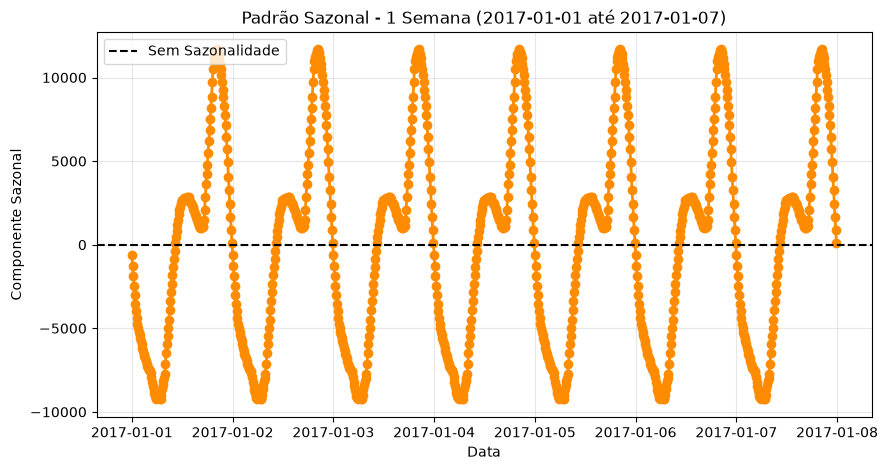

In [14]:
plt.figure(figsize=(10,5))

plt.plot(sazonalidade_semana, color="darkorange", linewidth=2.0, marker='o')
plt.axhline(0.0, color='black', linestyle='--', label='Sem Sazonalidade')
plt.title("Padrão Sazonal - 1 Semana (2017-01-01 até 2017-01-07)")
plt.xlabel("Data")
plt.ylabel("Componente Sazonal")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Observação

O componente sazonal apresenta um padrão diário claramente repetitivo ao longo da semana, com períodos de baixa demanda seguidos por elevações acentuadas no consumo.

A repetição desse comportamento em dias consecutivos confirma a presença de uma forte sazonalidade intradiária na série.

## 4.6 Análise dos Resíduos

Os resíduos da decomposição são analisados para verificar quanto da dinâmica da série permanece sem explicação após a remoção da tendência e da sazonalidade.

Um comportamento adequado é caracterizado por resíduos concentrados em torno de zero, sem padrões sistemáticos e com variabilidade relativamente estável ao longo do tempo.

In [15]:
residuo = decomp_adit.resid.dropna()

In [16]:
print("Estatísticas descritivas do resíduo (modelo aditivo):")
print(residuo.describe().round(3))
print("\nUm bom resíduo deve apresentar:")
print("- média próxima de zero")
print("- ausência de tendência")
print("- ausência de sazonalidade")
print("- baixa autocorrelação")

Estatísticas descritivas do resíduo (modelo aditivo):
count    52272.000
mean         0.642
std       2275.260
min     -14225.499
25%      -1278.424
50%        -17.184
75%       1161.516
max      13315.665
Name: resid, dtype: float64

Um bom resíduo deve apresentar:
- média próxima de zero
- ausência de tendência
- ausência de sazonalidade
- baixa autocorrelação


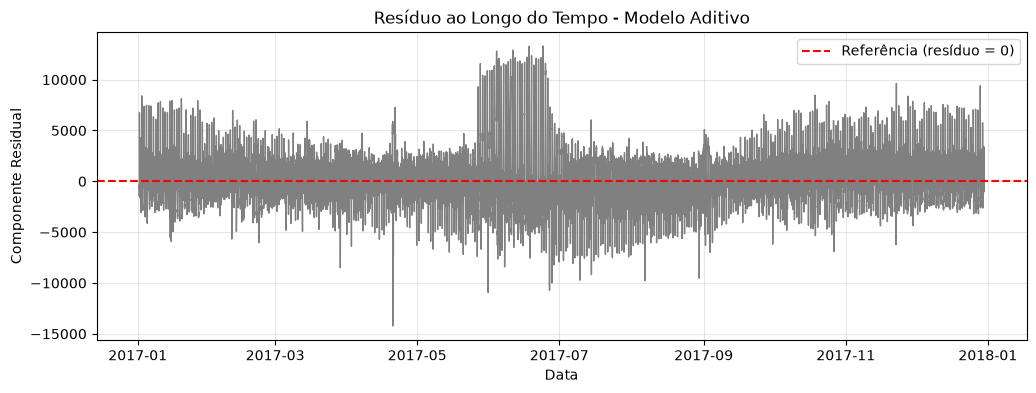

In [17]:
plt.figure(figsize=(12, 4))

plt.plot(residuo.index, residuo, color='gray', linewidth=1)
plt.axhline(0.0, color='red', linestyle='--', label='Referência (resíduo = 0)')
plt.title("Resíduo ao Longo do Tempo - Modelo Aditivo")
plt.xlabel("Data")
plt.ylabel("Componente Residual")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

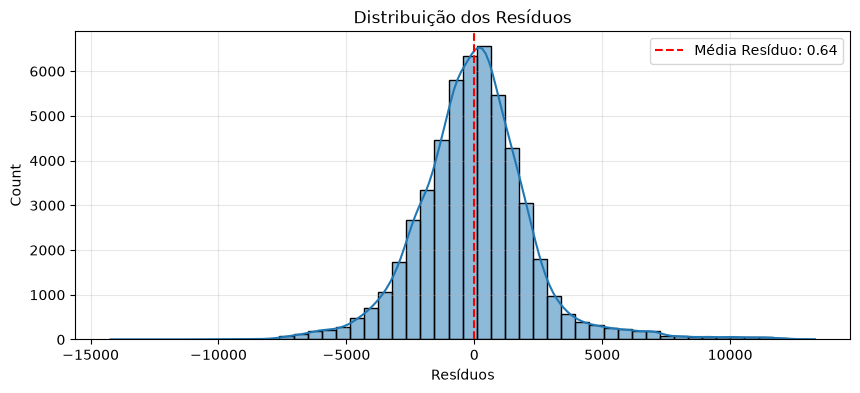

In [18]:
plt.figure(figsize=(10, 4))

sns.histplot(residuo, bins=50, kde=True)
plt.axvline(residuo.mean(), color='red', linestyle='--', label=f"Média Resíduo: {residuo.mean():.2f}")
plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduos")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Observação

Os resíduos apresentam média próxima de zero, indicando que a decomposição não introduz um viés sistemático relevante.

Entretanto, observa-se variação na dispersão ao longo do ano, especialmente em determinados períodos, além da presença de valores extremos. A distribuição também apresenta caudas relativamente longas, sugerindo que tendência e sazonalidade não explicam completamente toda a variabilidade do consumo.

Esses resultados indicam a necessidade de investigar posteriormente a dependência temporal remanescente por meio das funções de autocorrelação.

## 4.7 Verificação de Estacionariedade

A estacionariedade da série é avaliada por meio do teste Augmented Dickey-Fuller (ADF), cuja hipótese nula considera a presença de raiz unitária.

Valores de `p-value` inferiores a 0,05 indicam evidência estatística para rejeitar a hipótese nula.

In [22]:
# Teste ADF
adf_result = adfuller(dados['consumo_zona_1'])
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}') # p> 0.05 -> não é estacionária

if adf_result[1] > 0.05:
    print('\nA série provavelmente NÃO é estacionária (p-valor > 0.05).')
else:
    print('\nA série provavelmente é estacionária (p-valor <= 0.05).')

ADF Statistic: -32.121278534626164
p-value: 0.0

A série provavelmente é estacionária (p-valor <= 0.05).


C:\Users\Unisalesiano\AppData\Local\Temp\ipykernel_5616\3114601032.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(dados['consumo_zona_1'])


### Observação

O teste ADF apresentou estatística de aproximadamente **-32,12** e `p-value` igual a **0,0**, indicando forte evidência para rejeitar a hipótese de raiz unitária.

Portanto, a série pode ser considerada estacionária sob o critério do teste ADF.

Ainda assim, esse resultado não elimina a presença de sazonalidade ou dependência temporal, que serão analisadas nas próximas etapas.

## 4.8 Análise de Autocorrelação — ACF e PACF

As funções de autocorrelação (ACF) e autocorrelação parcial (PACF) são utilizadas para investigar a dependência temporal da série e identificar estruturas recorrentes entre observações defasadas.

Como os dados possuem frequência de 10 minutos, são analisados até **144 lags**, correspondentes a um ciclo completo de 24 horas.

### 4.8.1 ACF e PACF da Série Original

Inicialmente, a ACF e a PACF são analisadas diretamente sobre a série original para avaliar a intensidade da dependência temporal e verificar a presença do padrão sazonal diário.

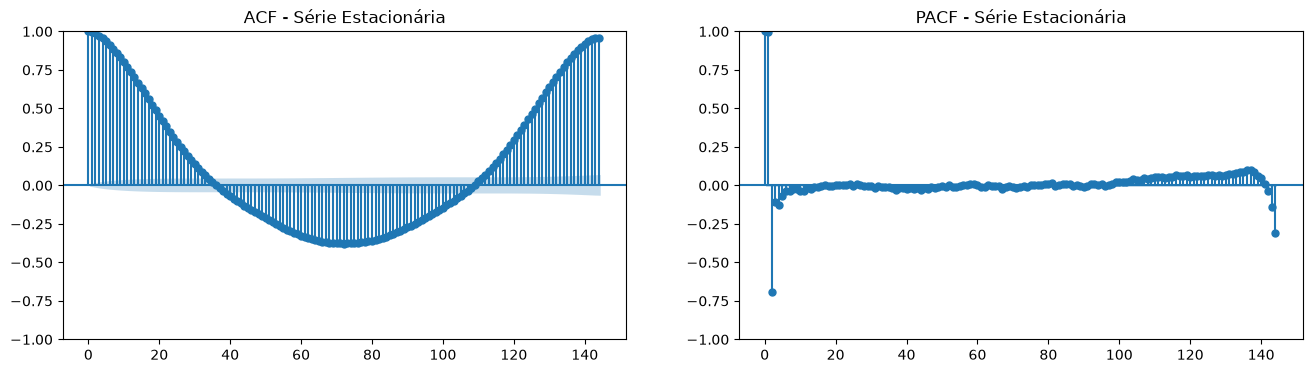

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(dados["consumo_zona_1"], lags=144, ax=ax[0], title="ACF - Série Estacionária")

plot_pacf(dados["consumo_zona_1"], lags=144, ax=ax[1], title="PACF - Série Estacionária")

plt.show()

### Observação

A ACF apresenta um comportamento cíclico bem definido, com correlações positivas nos primeiros lags, valores negativos próximos de meio dia e nova elevação em torno do lag **144**.

Esse padrão reforça a presença de uma forte sazonalidade diária. A PACF também apresenta influência expressiva nos primeiros lags, indicando elevada dependência entre observações consecutivas.

### 4.8.2 Diferenciação Sazonal

Para reduzir o efeito da sazonalidade diária, é aplicada uma diferenciação de **144 períodos**, comparando cada observação com o valor registrado no mesmo horário do dia anterior.

Após essa transformação, ACF e PACF são analisadas novamente para verificar a dependência temporal remanescente.

In [26]:
serie = dados["consumo_zona_1"]

serie_diff_sazonal = serie.diff(144).dropna()

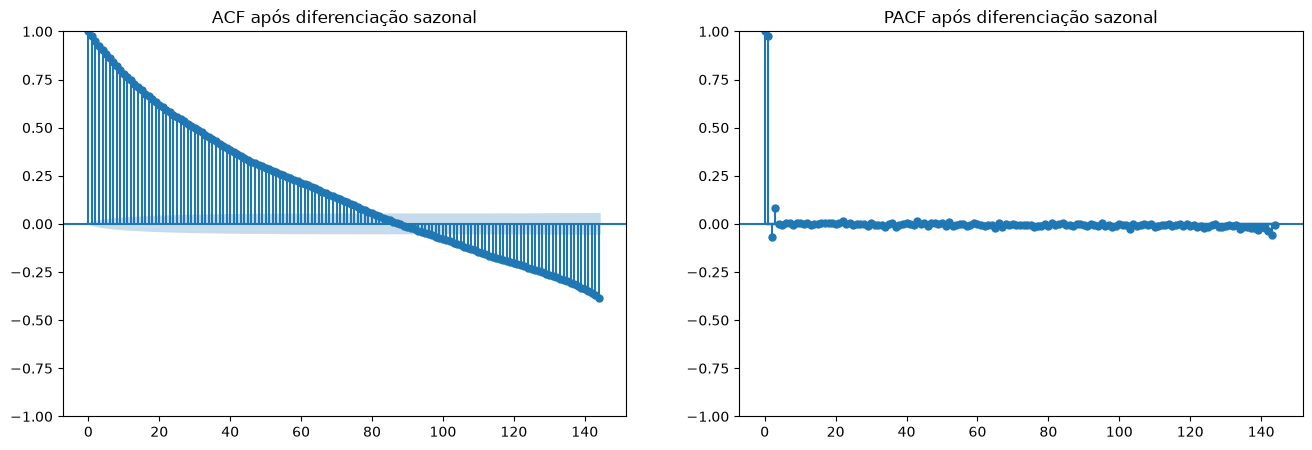

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(serie_diff_sazonal, lags=144, ax=ax[0], title="ACF após diferenciação sazonal")

plot_pacf(serie_diff_sazonal, lags=144, ax=ax[1], title="PACF após diferenciação sazonal")

plt.show()

### Observação

A diferenciação sazonal reduz parte da estrutura periódica original, porém a ACF ainda apresenta uma queda gradual ao longo dos lags.

Isso indica que, mesmo após remover parte do efeito diário, ainda existe dependência temporal relevante na série.

### 4.8.3 Diferenciação Regular e Sazonal

Em seguida, é aplicada uma diferenciação regular de primeira ordem juntamente com a diferenciação sazonal de 144 períodos.

O objetivo é avaliar como a combinação das duas transformações afeta a estrutura de autocorrelação da série.

In [ ]:
serie_diff_completa = (
    dados["consumo_zona_1"]
    .diff()       # diferenciação regular d=1
    .diff(144)    # diferenciação sazonal diária D=1 e S=144
    .dropna()
)

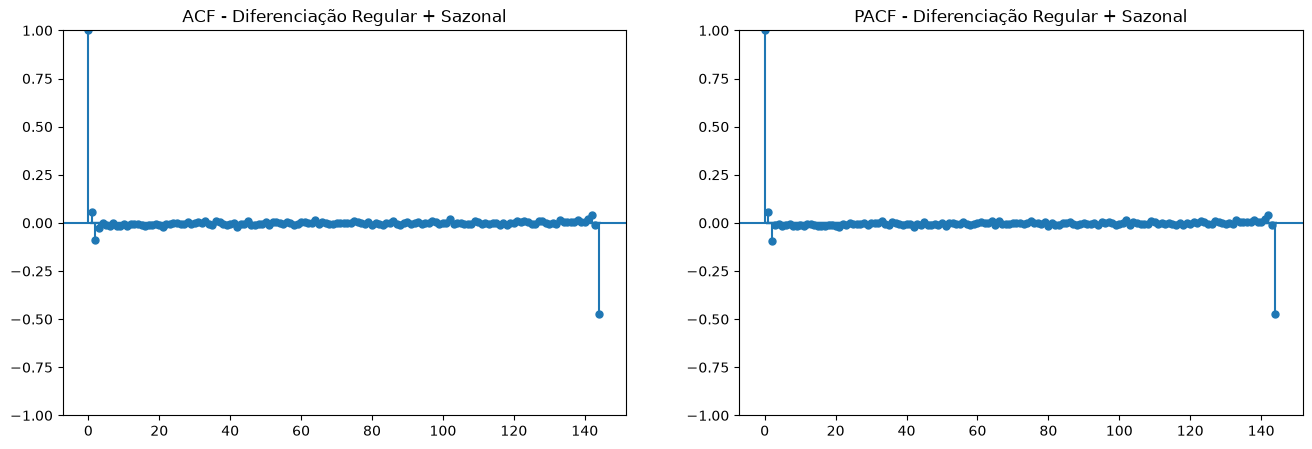

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(serie_diff_completa, lags=144, ax=ax[0], title="ACF - Diferenciação Regular + Sazonal")

plot_pacf(serie_diff_completa, lags=144, ax=ax[1], title="PACF - Diferenciação Regular + Sazonal")

plt.show()

### Observação

Após a diferenciação regular e sazonal, a maior parte das autocorrelações fica próxima de zero, indicando uma redução significativa da dependência temporal observada anteriormente.

Entretanto, permanece um pico negativo expressivo próximo ao lag **144**, mostrando que ainda existe estrutura associada ao ciclo diário.

O teste ADF apresenta novamente `p-value` próximo de zero, confirmando a ausência de evidência de raiz unitária após as transformações.

Como a série original já apresentou estacionariedade no teste ADF, a diferenciação regular deve ser interpretada com cautela, pois uma transformação excessiva pode introduzir sinais de sobrediferenciação.

In [33]:
adf_result = adfuller(serie_diff_completa)

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

ADF Statistic: -38.8521
p-value: 0.0000


C:\Users\Unisalesiano\AppData\Local\Temp\ipykernel_5616\1366467469.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(serie_diff_completa)


# 5. Análise das Variáveis Numéricas

Nesta etapa, são analisadas as variáveis meteorológicas presentes na base e sua relação com o consumo energético da Zona 1.

O objetivo é compreender suas distribuições, identificar associações lineares e avaliar quais variáveis apresentam maior relação com a demanda de energia.

## 5.1 Distribuição das Variáveis Numéricas

Inicialmente, são analisadas as distribuições das variáveis meteorológicas e do consumo energético.

Essa análise permite identificar diferenças de escala, concentração dos valores, assimetrias e comportamentos específicos de cada variável.

In [36]:
var_numericas = ['temperatura','umidade','velocidade_vento','fluxo_difuso_geral','fluxo_difuso','consumo_zona_1']

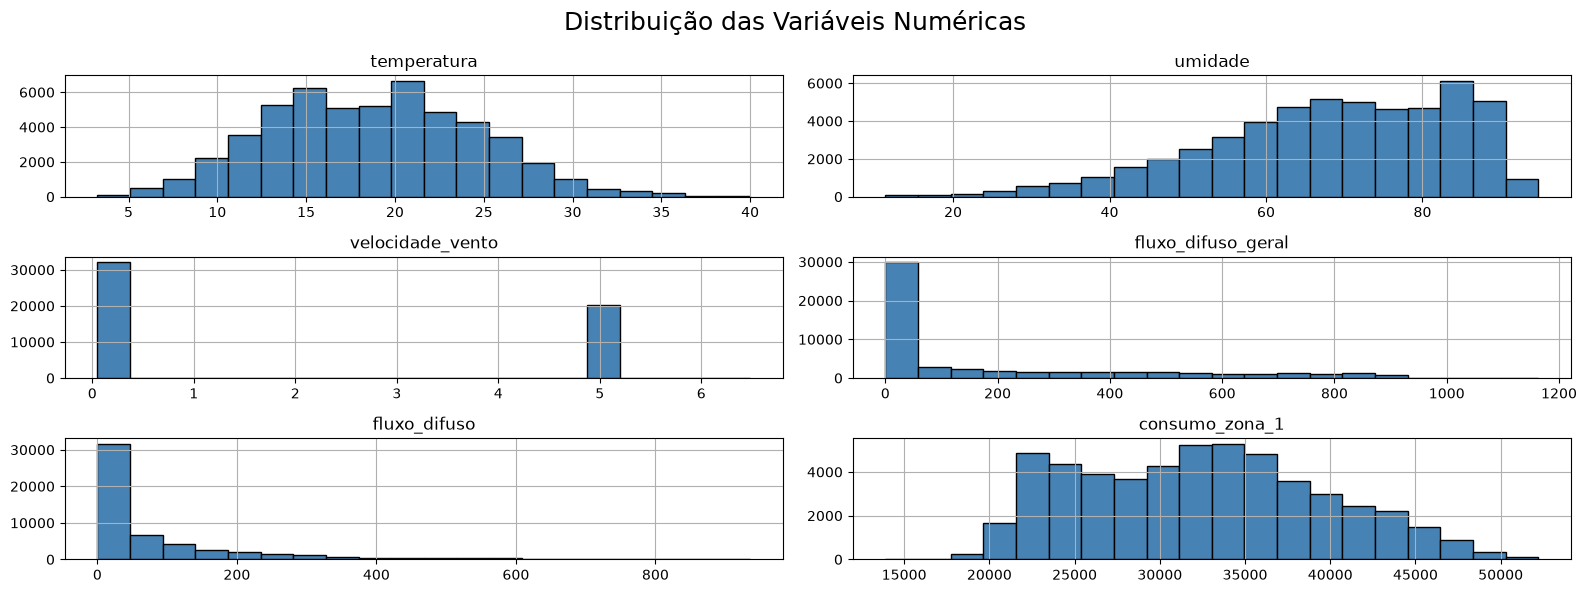

In [38]:
dados[var_numericas].hist(figsize=(16, 6), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=18)
plt.tight_layout()
plt.show()

### Observação

As variáveis apresentam distribuições bastante distintas. Temperatura e umidade possuem maior dispersão ao longo de seus intervalos, enquanto os fluxos difusos apresentam forte concentração em valores baixos e assimetria à direita.

A velocidade do vento apresenta concentração em faixas específicas, indicando um comportamento diferente das demais variáveis contínuas.

## 5.2 Correlação entre as Variáveis

A matriz de correlação é utilizada para avaliar a intensidade e a direção das relações lineares entre as variáveis numéricas.

Valores próximos de `1` indicam associação positiva, enquanto valores próximos de `-1` representam associação negativa.

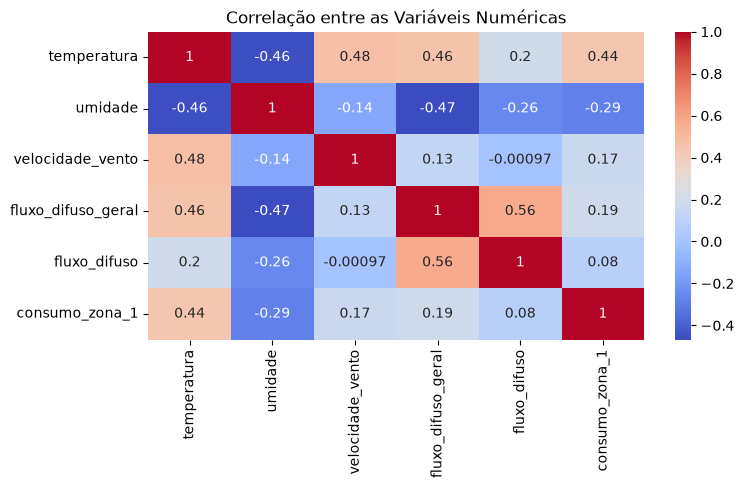

In [48]:
corr = dados[var_numericas].corr()

plt.figure(figsize=(8,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlação entre as Variáveis Numéricas")
plt.show()

### Observação

A temperatura apresenta a maior correlação positiva com o consumo da Zona 1, com aproximadamente **0,44**.

A umidade apresenta correlação negativa de aproximadamente **-0,29**, enquanto velocidade do vento e variáveis de fluxo possuem relações lineares mais fracas com o consumo.

Também são observadas correlações entre algumas variáveis meteorológicas, como temperatura, umidade e fluxo difuso geral.

## 5.3 Relação das Variáveis com o Consumo

As correlações são analisadas diretamente em relação à variável-alvo `consumo_zona_1`, permitindo comparar quais variáveis apresentam maior associação linear com a demanda energética.

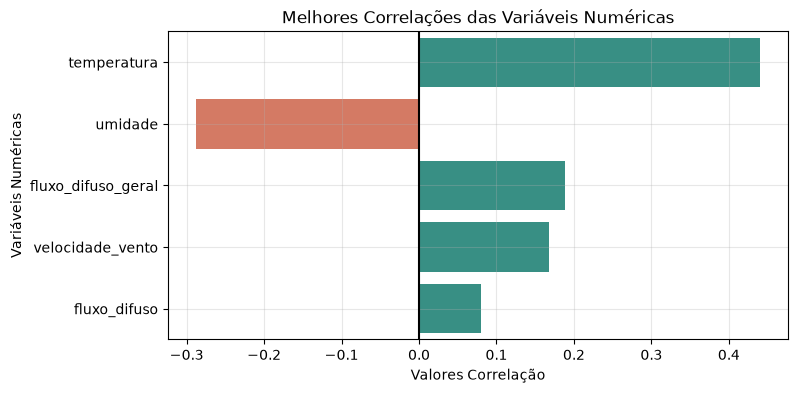

In [53]:
corr_target = (corr["consumo_zona_1"].drop("consumo_zona_1").sort_values(key=abs, ascending=False))

plt.figure(figsize=(8,4))

cores = ["#2a9d8f" if valor >= 0 else "#e76f51"
         for valor in corr_target.values]

sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index ,palette=cores)
plt.axvline(0.0, color='black', linewidth=1.5)
plt.title("Melhores Correlações das Variáveis Numéricas")
plt.xlabel("Valores Correlação")
plt.ylabel("Variáveis Numéricas")
plt.grid(alpha=0.3)
plt.show()

### Observação

Entre as variáveis meteorológicas, a **temperatura** apresenta a associação linear mais relevante com o consumo, seguida pela **umidade**, que possui relação negativa.

As demais variáveis apresentam correlações mais baixas, indicando que seu efeito isolado sobre o consumo tende a ser menos evidente em uma análise puramente linear.

## 5.4 Relação entre Variáveis Meteorológicas e Consumo

Os gráficos de dispersão permitem observar individualmente a relação entre cada variável meteorológica e o consumo energético.

Uma linha de tendência linear é adicionada como referência para facilitar a identificação da direção geral das relações.

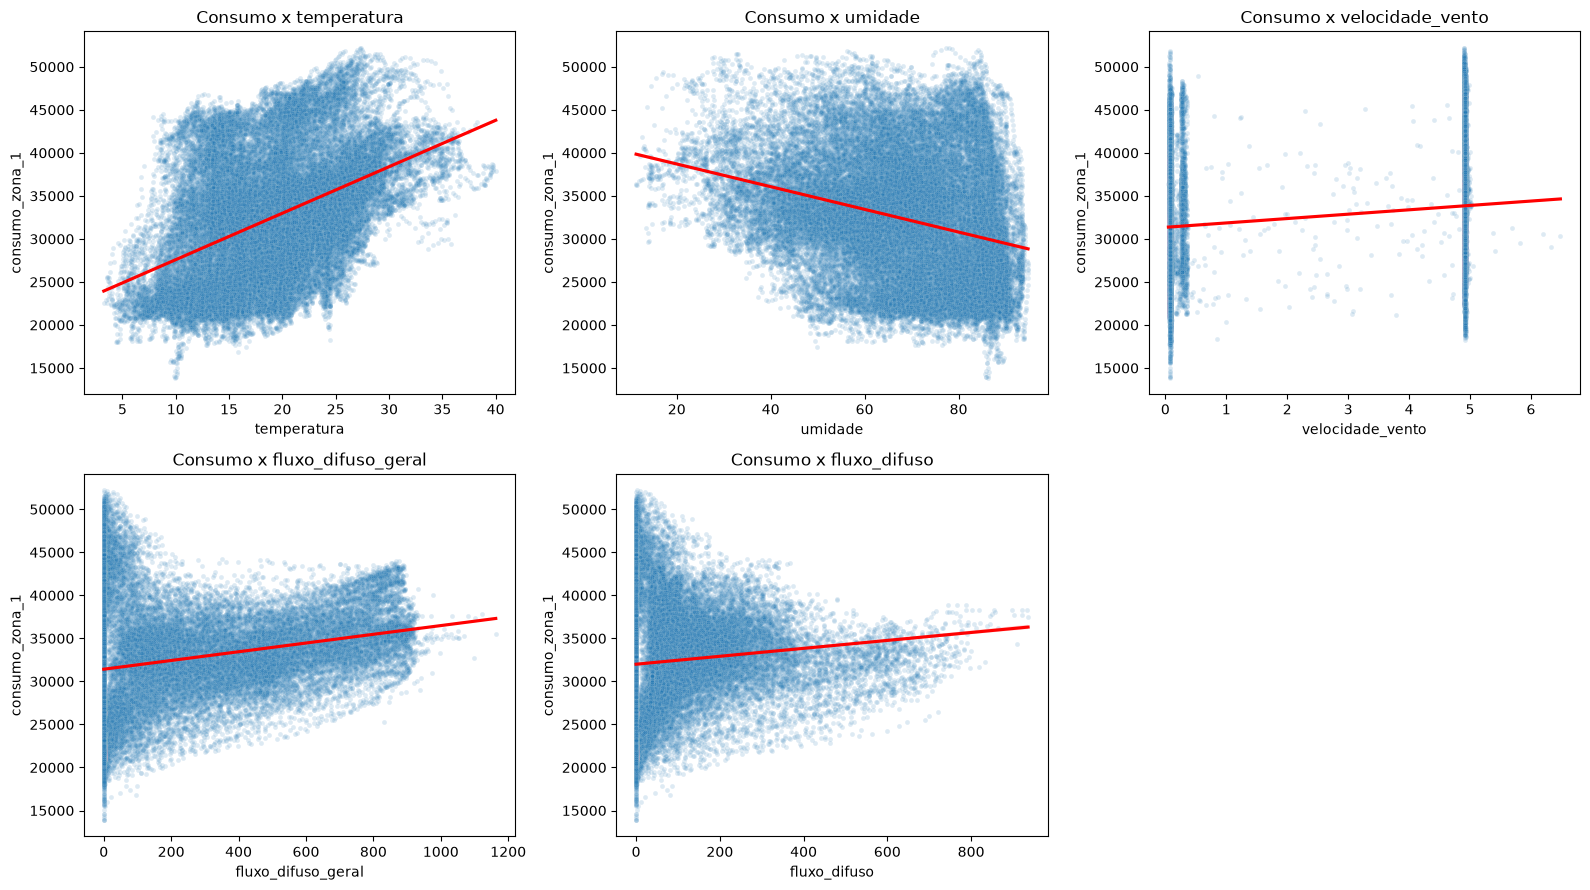

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

variaveis_explicativas = ["temperatura", "umidade", "velocidade_vento", "fluxo_difuso_geral", "fluxo_difuso"]

for ax, coluna in zip(axes.flat, variaveis_explicativas):

    sns.scatterplot(data=dados, x=coluna, y="consumo_zona_1", alpha=0.15, s=12, ax=ax)
    sns.regplot(data=dados, x=coluna, y="consumo_zona_1", scatter=False, color="red", ax=ax)

    ax.set_title(f"Consumo x {coluna}")

# remove o último subplot vazio
axes.flat[-1].axis("off")

plt.tight_layout()
plt.show()

### Observação

Os gráficos reforçam a associação positiva entre temperatura e consumo e a relação negativa observada para a umidade.

Entretanto, existe ampla dispersão dos valores em praticamente todas as variáveis, indicando que o consumo não é explicado adequadamente por um único fator meteorológico.

Esse comportamento sugere uma relação multivariada e possivelmente não linear, reforçando a utilização conjunta de informações meteorológicas e temporais na etapa de modelagem.

# 6. Conclusão da Análise Exploratória

A análise exploratória permitiu identificar os principais padrões presentes na série de consumo energético da Zona 1.

Os principais achados foram:

- **Sazonalidade intradiária forte:** a série apresenta um ciclo diário bem definido, compatível com a frequência de 10 minutos e com repetição a cada 144 observações.
- **Variação ao longo do ano:** o consumo aumenta principalmente entre junho e agosto e apresenta redução mais evidente nos meses finais.
- **Efeito do dia da semana:** o comportamento é relativamente estável entre segunda e sábado, enquanto os domingos apresentam menor consumo médio.
- **Tendência e sazonalidade presentes:** a decomposição mostrou que parte importante da série pode ser explicada por esses componentes, embora os resíduos ainda apresentem variabilidade relevante.
- **Estacionariedade estatística:** o teste ADF rejeitou a hipótese de raiz unitária, indicando estacionariedade sob esse critério.
- **Dependência temporal elevada:** ACF e PACF evidenciaram forte autocorrelação e estrutura associada ao ciclo diário.
- **Influência meteorológica:** a temperatura apresentou a maior correlação positiva com o consumo, enquanto a umidade apresentou relação negativa.
- **Comportamento multivariado:** nenhuma variável meteorológica isolada explica completamente a demanda, indicando a importância de combinar informações externas com características temporais da própria série.

Com base nesses resultados, a etapa de modelagem poderá explorar **lags, médias móveis, variáveis de calendário e informações meteorológicas**, buscando representar de forma mais adequada a dinâmica temporal do consumo energético.